In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info

<bound method DataFrame.info of      CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>

In [6]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
X = df.iloc[:,[3,4]].values
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

### WCSS -> Within Clusters Sum Of Squares

In [14]:
# finding wcss values for different no. of clusters

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

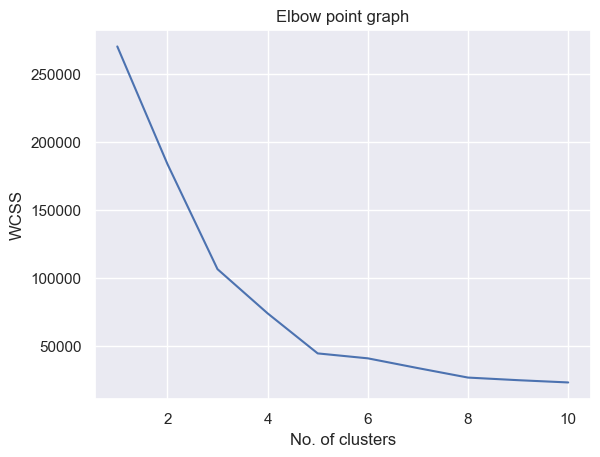

In [15]:
#Plotting elbow graph
sns.set()
plt.plot(range(1,11),wcss)
plt.title('Elbow point graph')
plt.xlabel('No. of clusters')
plt.ylabel('WCSS')
plt.show()

#### Optimum number of clusters = 5

In [18]:
# Training the K-Means model
kmeans = KMeans(n_clusters=5, init='k-means++', random_state = 0)
# Return a label for each data point based on their clusters
Y = kmeans.fit_predict(X)
print(Y)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


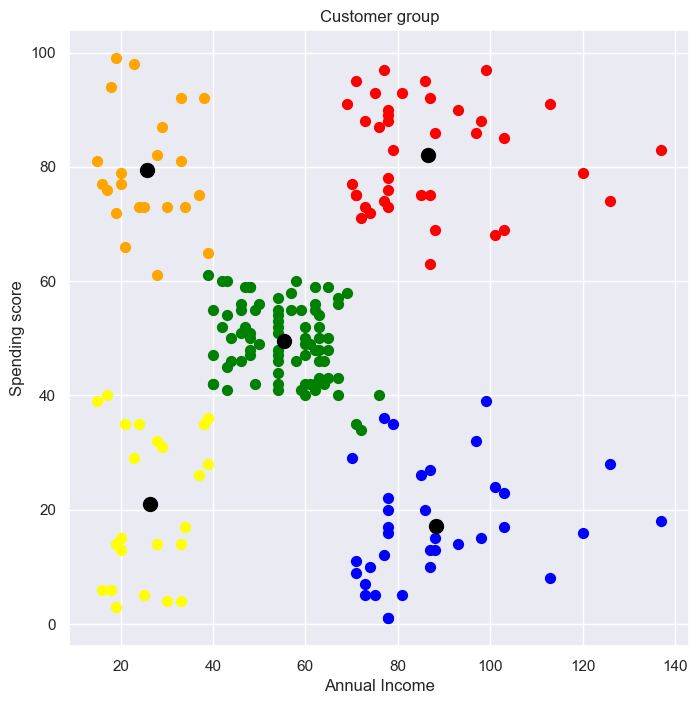

In [20]:
# Plotting all the clusters and their centroids
plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0],X[Y==0,1], s=50, c='green',label='cluster 1')
plt.scatter(X[Y==1,0],X[Y==1,1], s=50, c='red',label='cluster 2')
plt.scatter(X[Y==2,0],X[Y==2,1], s=50, c='blue',label='cluster 3')
plt.scatter(X[Y==3,0],X[Y==3,1], s=50, c='yellow',label='cluster 4')
plt.scatter(X[Y==4,0],X[Y==4,1], s=50, c='orange',label='cluster 5')

# Plotting Centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='black', label='centroids')
plt.title('Customer group')
plt.xlabel('Annual Income')
plt.ylabel('Spending score')
plt.show()

***Attempt 2***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
#Select Features for Clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [5]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
#Finding Optimal Clusters using Elbow Method
inertia = []
K = range(2, 11)  # Testing 2 to 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

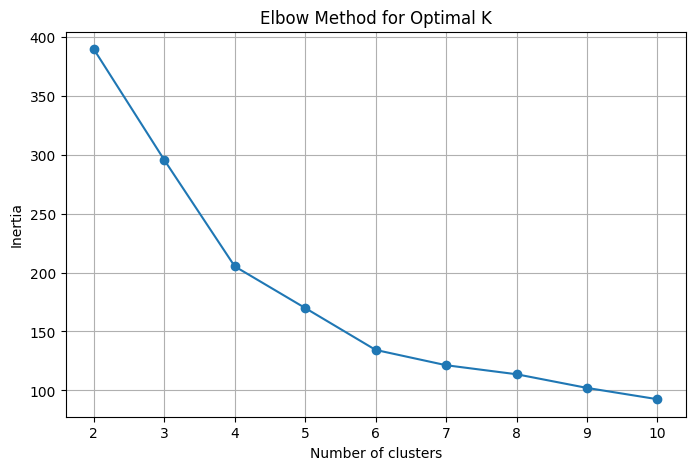

In [7]:
# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.grid()
plt.show()


In [8]:
#Silhouette Score Validation
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")


K = 2, Silhouette Score = 0.3355
K = 3, Silhouette Score = 0.3579
K = 4, Silhouette Score = 0.4040
K = 5, Silhouette Score = 0.4085
K = 6, Silhouette Score = 0.4311
K = 7, Silhouette Score = 0.4101
K = 8, Silhouette Score = 0.3674
K = 9, Silhouette Score = 0.3744
K = 10, Silhouette Score = 0.3619


In [9]:
#Based on Elbow + Silhouette Score, let's select k = 3
optimal_k = 3

In [10]:
#Apply K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [11]:
#Labeling Clusters (business interpretation)
cluster_map = {
    0: "Medium-Value",
    1: "High-Value",
    2: "Low-Value"
}
df['Customer_Segment'] = df['Cluster'].map(cluster_map)

print(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Customer_Segment']].head())


   Age  Annual Income (k$)  Spending Score (1-100) Customer_Segment
0   19                  15                      39        Low-Value
1   21                  15                      81        Low-Value
2   20                  16                       6        Low-Value
3   23                  16                      77        Low-Value
4   31                  17                      40        Low-Value


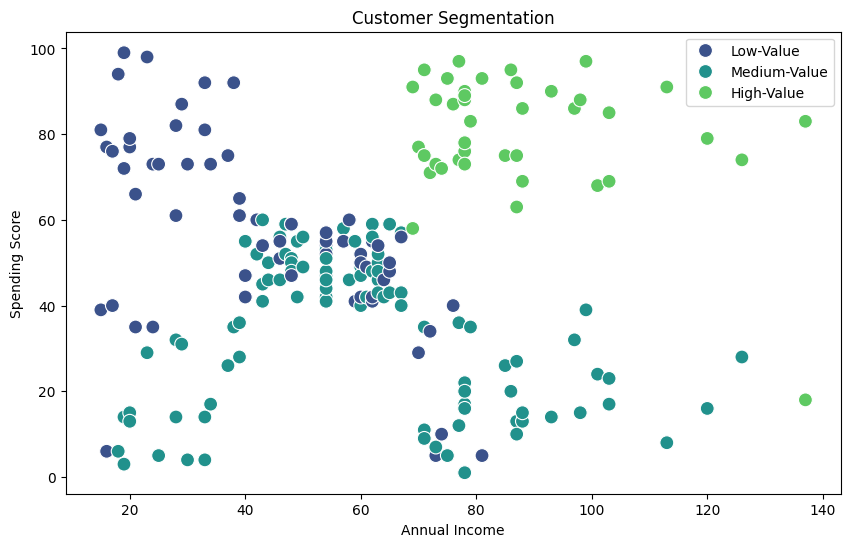

In [12]:
#Visualization - 2D Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,
                x='Annual Income (k$)',
                y='Spending Score (1-100)',
                hue='Customer_Segment',
                palette='viridis',
                s=100)
plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

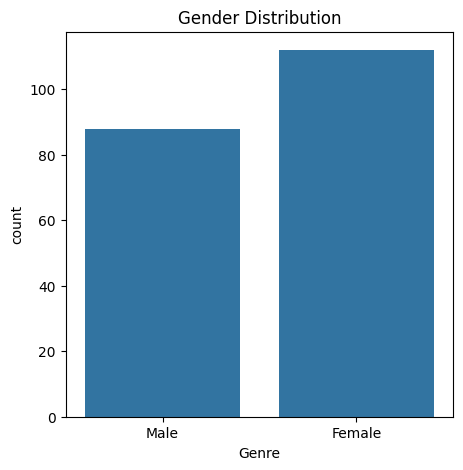

In [15]:
#Exploratory Data Analysis
#Gender Distribution
plt.figure(figsize=(5,5))
sns.countplot(data=df, x='Genre')
plt.title("Gender Distribution")
plt.show()

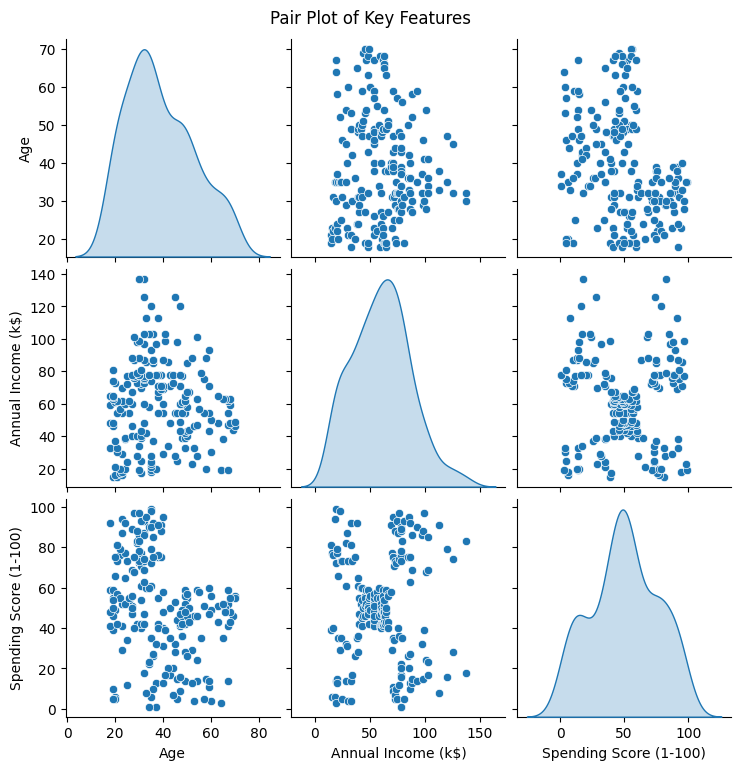

In [16]:
#Pair plot
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']], diag_kind='kde')
plt.suptitle("Pair Plot of Key Features", y=1.02)
plt.show()